# SVM Baseline

Dieses Notebook laedt die SVM-Konfiguration, baut Event-Fenster aus `Daten/Daten_Labeled` und berechnet Precision, Recall, F1 sowie die grafische Confusion Matrix fuer den Modellvergleich.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "svm_baseline").exists():
            return candidate
    raise FileNotFoundError("Repo root mit src/svm_baseline wurde nicht gefunden.")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.random_forest_baseline.data import prepare_dataset
from src.svm_baseline.config import SVMBaselineConfig
from src.svm_baseline.modeling import evaluate_grouped_dataset, save_confusion_matrix_plot

config = SVMBaselineConfig.from_json(repo_root / "baseline_models/svm/config.json")
config

SVMBaselineConfig(data_dir='Daten/Daten_Labeled', output_dir='baseline_models/svm/output', model_output_path='baseline_models/svm/output/svm_model.pkl', window_before_s=0.5, window_after_s=0.5, min_window_rows=25, labels=['Vorhand', 'Rueckhand', 'Schlaeger drehen', 'Aufschlag von unten', 'Kein Schlag / Other'], excluded_labels=['Unsicher'], min_samples_per_label=10, min_sessions_per_label=2, random_state=42, kernel='linear', c_value=0.5, gamma='scale', degree=3, coef0=0.0, class_weight='balanced', probability=True)

In [2]:
dataset = prepare_dataset(config)
display(dataset.label_summary)
display(dataset.metadata.head())
print(f"Events: {len(dataset.labels)} | Sessions: {dataset.groups.nunique()} | Features: {dataset.features.shape[1]}")

,label_name,total_events,session_count
0,Vorhand,170,3
1,Rueckhand,95,3
2,Schlaeger drehen,53,2
3,Aufschlag von unten,38,2
4,Kein Schlag / Other,21,3


,session_name,event_index,event_time_s,window_start_s,window_end_s,window_rows,label_name
0,fritz_1_Labeled.csv,11534,116.219257,115.719257,116.719257,99,Rueckhand
1,fritz_1_Labeled.csv,11832,119.222006,118.722006,119.722006,99,Rueckhand
2,fritz_1_Labeled.csv,12133,122.254987,121.754987,122.754987,99,Vorhand
3,fritz_1_Labeled.csv,12499,125.942926,125.442926,126.442926,99,Vorhand
4,fritz_1_Labeled.csv,12805,129.026281,128.526281,129.526281,99,Vorhand


Events: 377 | Sessions: 3 | Features: 164


In [3]:
result = evaluate_grouped_dataset(dataset, config)
display(pd.DataFrame([result.overall_metrics]))
display(result.classification_report)
display(result.fold_metrics)

,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,377.0,164.0,3.0,0.883289,0.741576,0.747125,0.741576,0.743661,0.888448


,label,precision,recall,f1-score,support
0,Vorhand,0.994118,0.994118,0.994118,170.000000
1,Rueckhand,0.967391,0.936842,0.951872,95.000000
2,Schlaeger drehen,0.714286,0.660377,0.686275,53.000000
3,Aufschlag von unten,0.948718,0.973684,0.961039,38.000000
4,Kein Schlag / Other,0.111111,0.142857,0.125000,21.000000
5,accuracy,0.883289,0.883289,0.883289,0.883289
6,macro avg,0.747125,0.741576,0.743661,377.000000
7,weighted avg,0.894281,0.883289,0.888448,377.000000


,fold,test_session,train_events,test_events,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,fritz_1_Labeled.csv,230,147,0.823129,0.809255,0.792787,0.809255,0.666535,0.860356
1,2,fritz_2_Labeled.csv,292,85,0.929412,0.666667,0.488636,0.500000,0.494186,0.923666
2,3,fritz_3_Labeled.csv,232,145,0.917241,0.828571,0.929748,0.828571,0.811340,0.890702


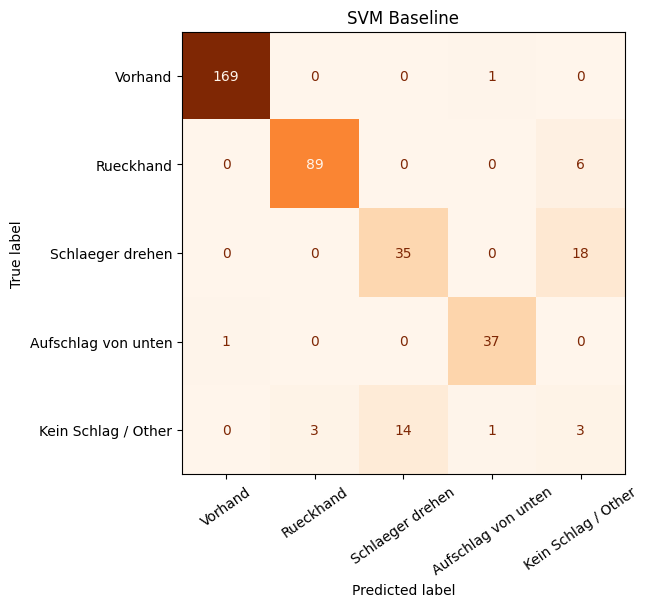

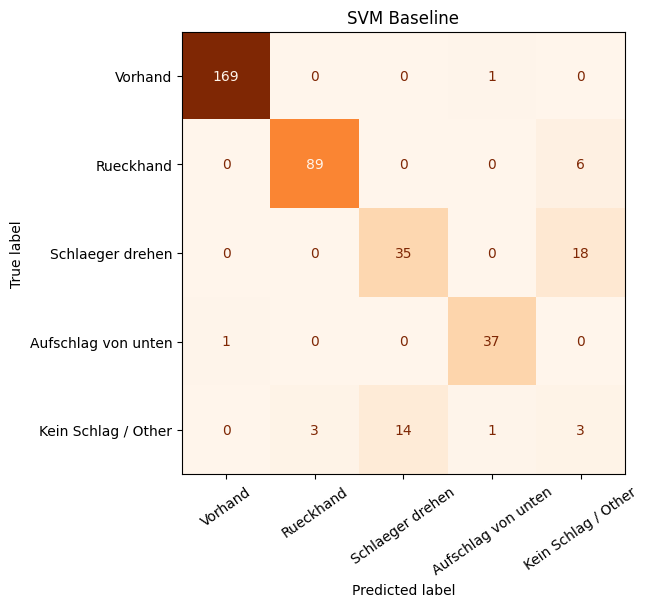

In [4]:
figure = save_confusion_matrix_plot(result.confusion_matrix)
figure

## Anpassung

Wenn ihr andere Labels oder SVM-Parameter testen wollt, passt `baseline_models/svm/config.json` an und fuehrt die Zellen erneut aus.